# Evaluation

The unweighted model is fit on January–October. Its operating threshold is the delayed-class F1 peak on the pooled out-of-fold predictions from those months. November–December is drawn only after that choice.

The plots below are written by `python -m sbahn.models.evaluate`.

operating threshold 0.30  development F1 0.647  development F1 at 0.50 0.633
November–December delayed recall 0.897  on-time recall 0.992  delayed F1 0.862


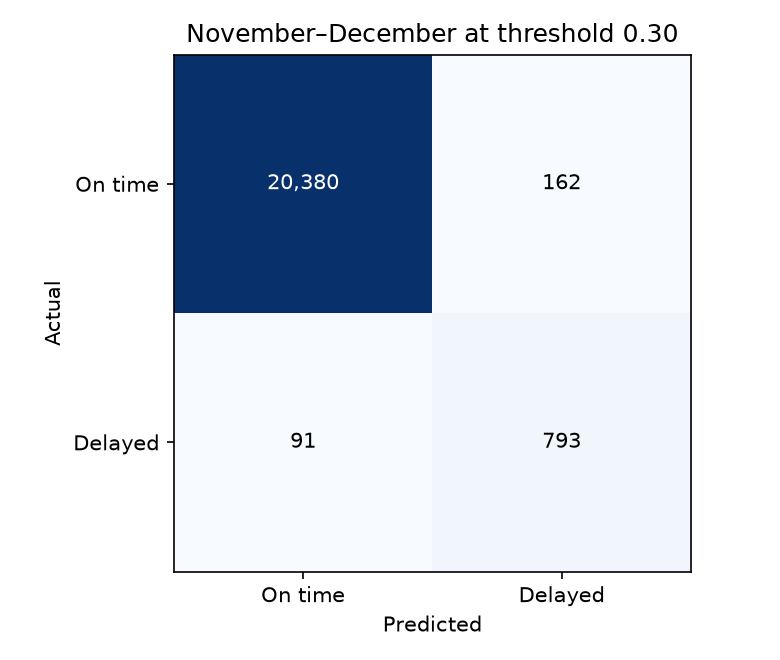

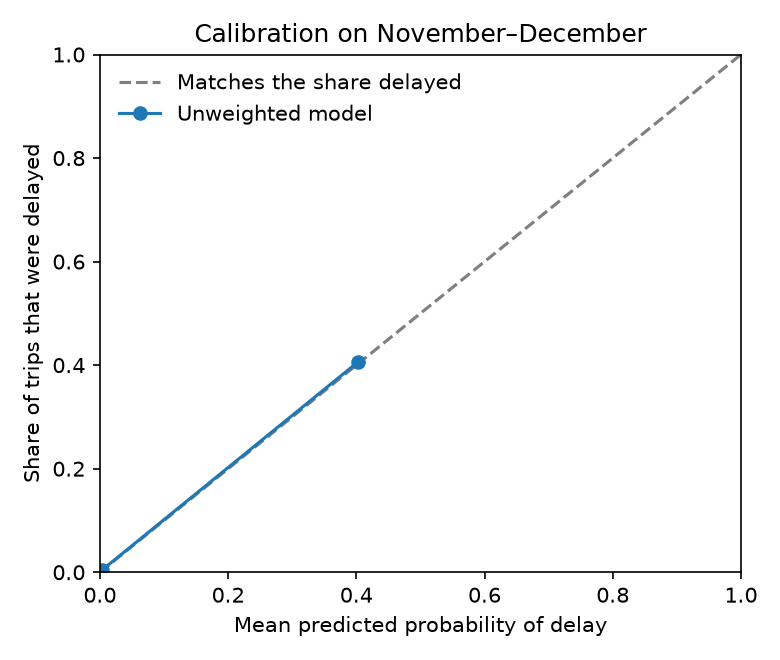

In [1]:
import json

from IPython.display import Image, display

from sbahn.config import PROJECT_ROOT

report = json.loads((PROJECT_ROOT / "reports" / "evaluation" / "operating_threshold.json").read_text(encoding="utf-8"))
print(
    f"operating threshold {report['threshold']:.2f}  "
    f"development F1 {report['development_f1']:.3f}  "
    f"development F1 at 0.50 {report['development_f1_at_0_5']:.3f}"
)
print(
    f"November–December delayed recall {report['test_recall_delayed']:.3f}  "
    f"on-time recall {report['test_recall_on_time']:.3f}  "
    f"delayed F1 {report['test_delayed_f1']:.3f}"
)
display(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "confusion_matrix.png")))
display(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "calibration_curve.png")))

The development F1 is highest at 0.30. The step at 0.35 is almost the same, and 0.50 is lower, so the operating cutoff moves from the search default of 0.50 to 0.30.

On November–December that cutoff catches 793 of 884 delayed trips and raises 162 false alarms. Delayed-class F1 there is 0.862, a little under the 0.874 scored at 0.50. The holdout is not used to walk the cutoff back.

On the calibration curve, nine of the ten equal-count bins sit at the origin: most trips get a probability near zero, and those trips are on time. The top bin lies on the diagonal, with a mean predicted probability of 0.40 and a delayed share of 0.41.

The same November–December predictions are grouped below. The model is fit once, at the baseline hyperparameters, and every trip is called delayed when its probability is at least 0.30. Weather bands are for the slice only: none is exactly 0 mm, light is above 0 through 2 mm, and heavy is above 2 mm.

In [1]:
import json

import pandas as pd
from IPython.display import display

from sbahn.config import PROJECT_ROOT

slices = json.loads((PROJECT_ROOT / "reports" / "evaluation" / "slices.json").read_text(encoding="utf-8"))
print(
    f"threshold {slices['threshold']:.2f}  "
    f"November–December trips {slices['test_rows']:,}"
)
for name, rows in slices["slices"].items():
    print(name)
    display(pd.DataFrame(rows))


threshold 0.30  November–December trips 21,426


group,n,delay_rate,precision,recall,f1
S1,3617,0.043683,0.911243,0.974684,0.941896
S2,3623,0.030914,0.844262,0.919643,0.880342
S41,3561,0.048301,0.759563,0.808140,0.783099
S42,3564,0.048822,0.790323,0.844828,0.816667
S5,3516,0.038680,0.881119,0.926471,0.903226
S7,3545,0.037236,0.815789,0.939394,0.873239


group,n,delay_rate,precision,recall,f1
0,865,0.042775,0.666667,0.864865,0.752941
1,866,0.027714,0.766667,0.958333,0.851852
2,868,0.039171,0.916667,0.970588,0.942857
3,885,0.051977,0.897959,0.956522,0.926316
4,892,0.040359,0.809524,0.944444,0.871795
5,901,0.033296,0.903226,0.933333,0.918033
6,913,0.033954,0.882353,0.967742,0.923077
7,906,0.046358,0.808511,0.904762,0.853933
8,898,0.043430,0.674419,0.743590,0.707317
9,846,0.055556,0.800000,0.765957,0.782609


group,n,delay_rate,precision,recall,f1
none,7610,0.034166,0.872340,0.946154,0.907749
light,5868,0.042945,0.818505,0.912698,0.863039
heavy,7948,0.046804,0.808673,0.852151,0.829843


group,n,delay_rate,precision,recall,f1
strike,565,0.936283,0.935714,0.990548,0.962351
incident,8,0.000000,0.000000,0.000000,0.000000
event,0,NaN,0.000000,0.000000,0.000000
none,20853,0.017024,0.681013,0.757746,0.717333


Delayed-class F1 on ordinary days, with no strike, incident, or event, is 0.717, well below the overall 0.862. Strike days sit the other way, at 0.962. By line, S41 is 0.783 and S1 is 0.942. By hour, 08:00 and 16:00 are 0.707 and 0.703, while 10:00, 14:00, and 20:00 are 0.985, 0.964, and 0.989. The event-day slice has no November–December trips. The incident slice has 8 trips, none of them delayed, so its F1 of 0 sits next to a row count of 8.


TreeSHAP explains the same November–December predictions. The values are log-odds of delay. The bar ranks features by mean absolute SHAP, and the beeswarm shows which direction each feature pushes. Each waterfall is the holdout trip closest to 0.30 in that error story.

expected log-odds -6.768
 1  line_mean_delay_prev_hour  0.426
 2  weather_condition  0.373
 3  route_key  0.330
 4  line_mean_delay_prev_day  0.259
 5  is_strike_day  0.126
 6  is_peak_hour  0.119
 7  line_delay_rate_prev_day  0.116
 8  wind_speed_kmh  0.112


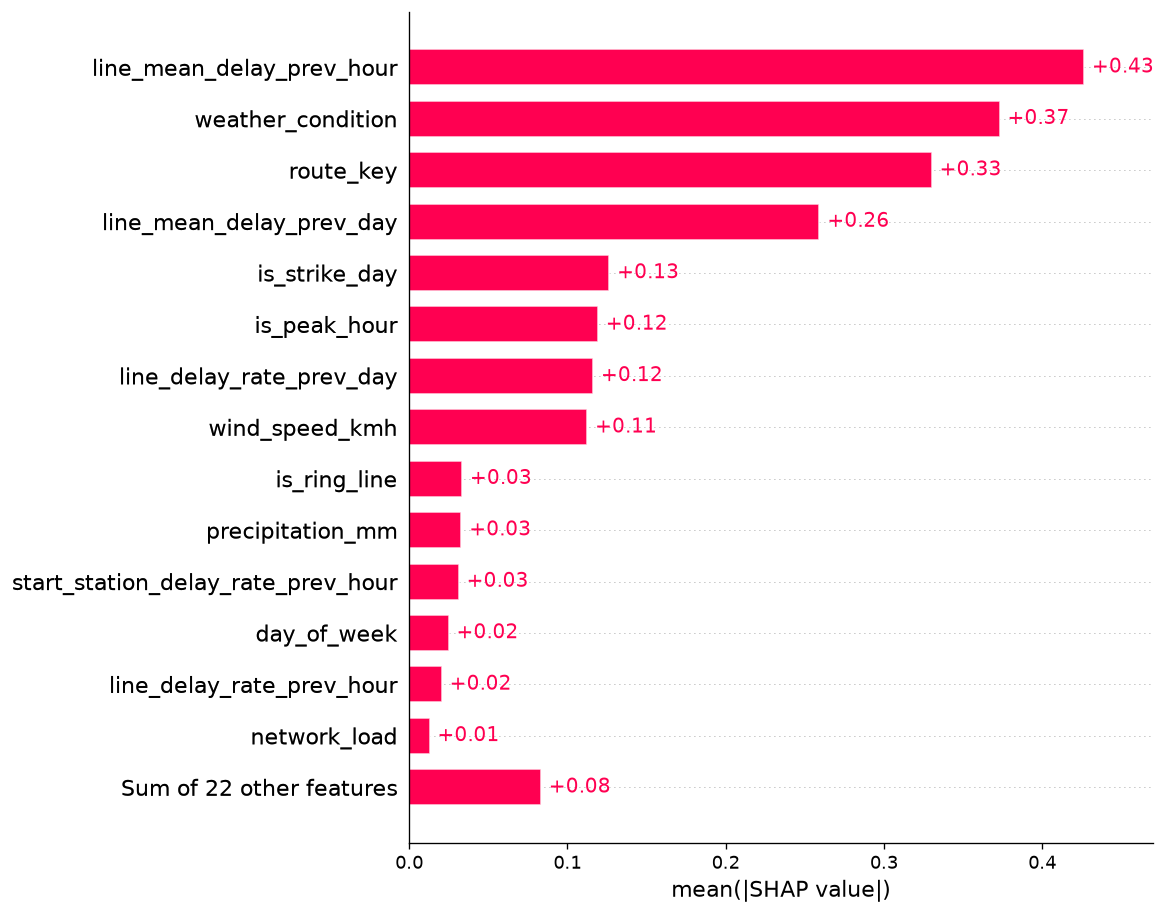

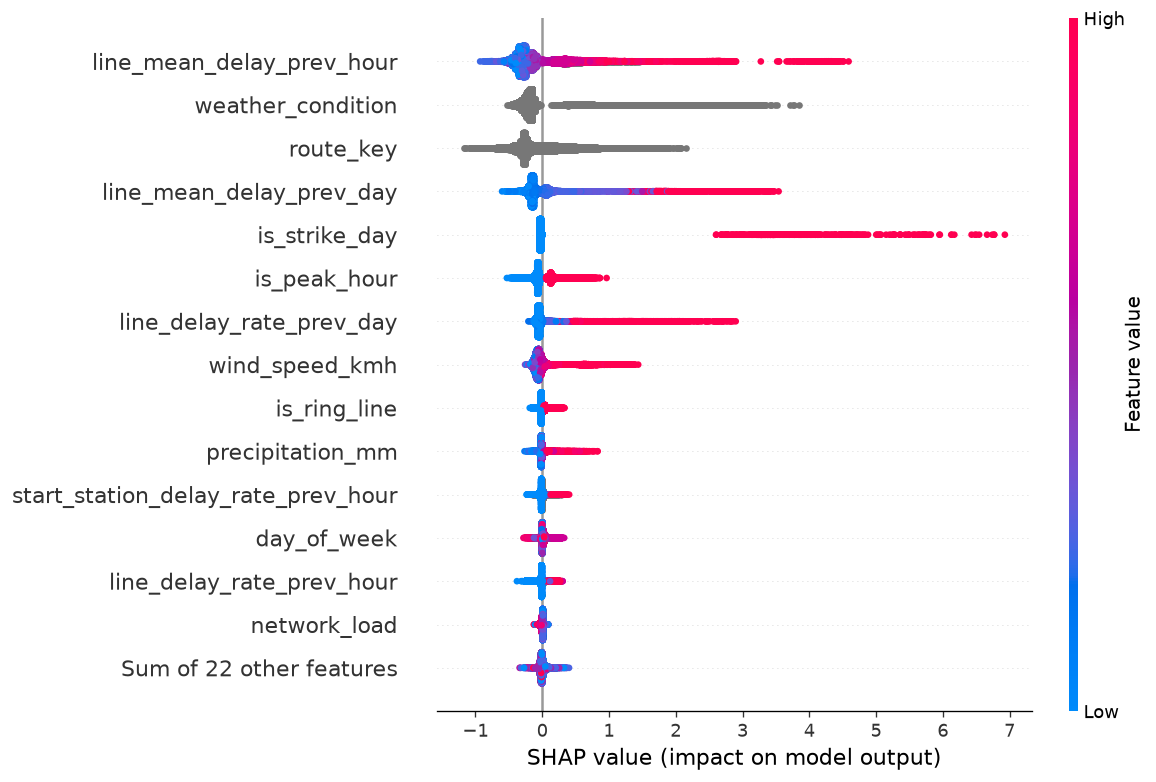

strike_caught: S41 hour 8  probability 0.304  is_strike_day +5.014


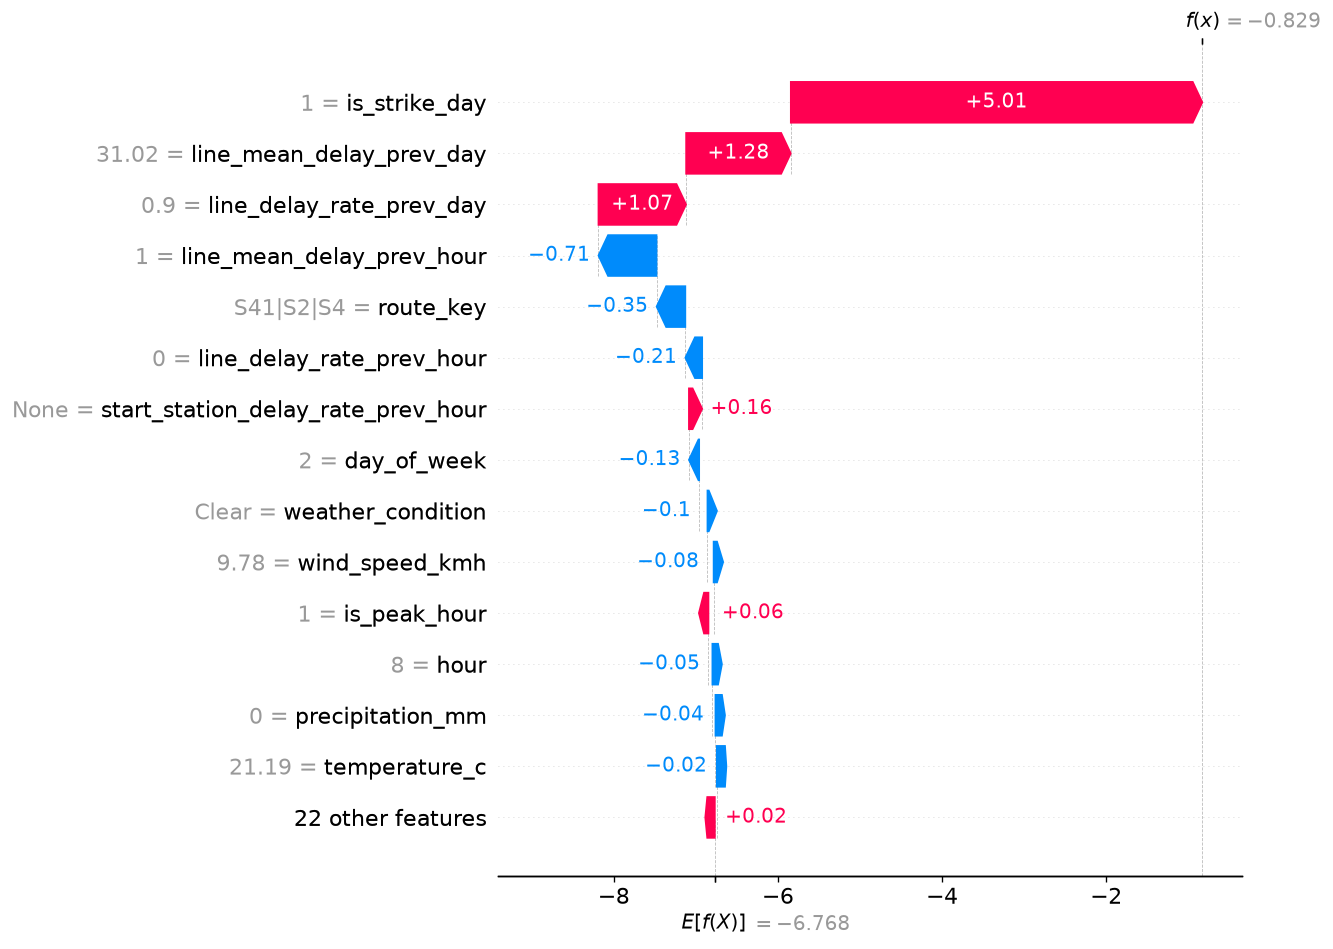

ordinary_miss: S42 hour 9  probability 0.279  weather_condition +2.914


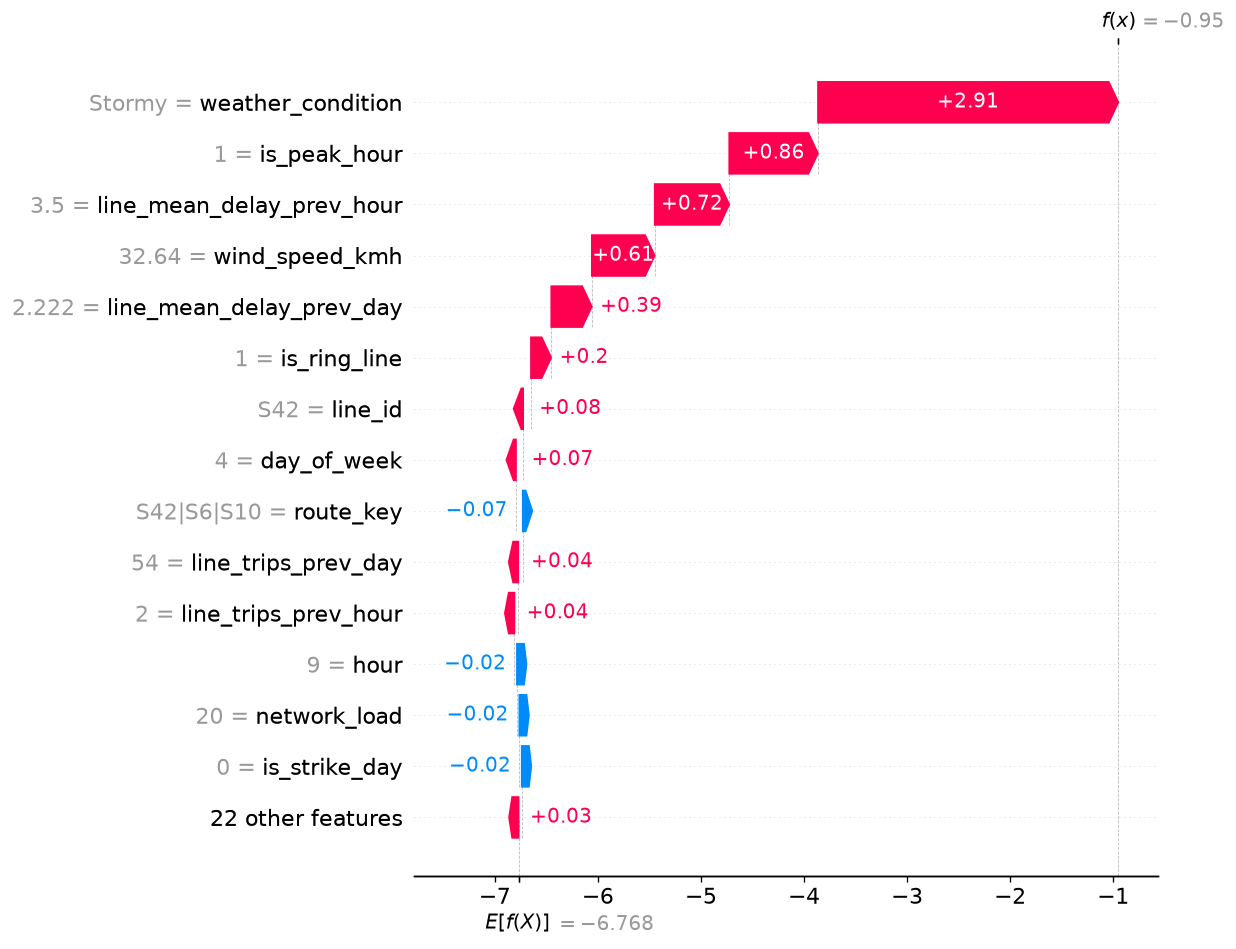

ordinary_false_alarm: S41 hour 8  probability 0.301  weather_condition +2.998


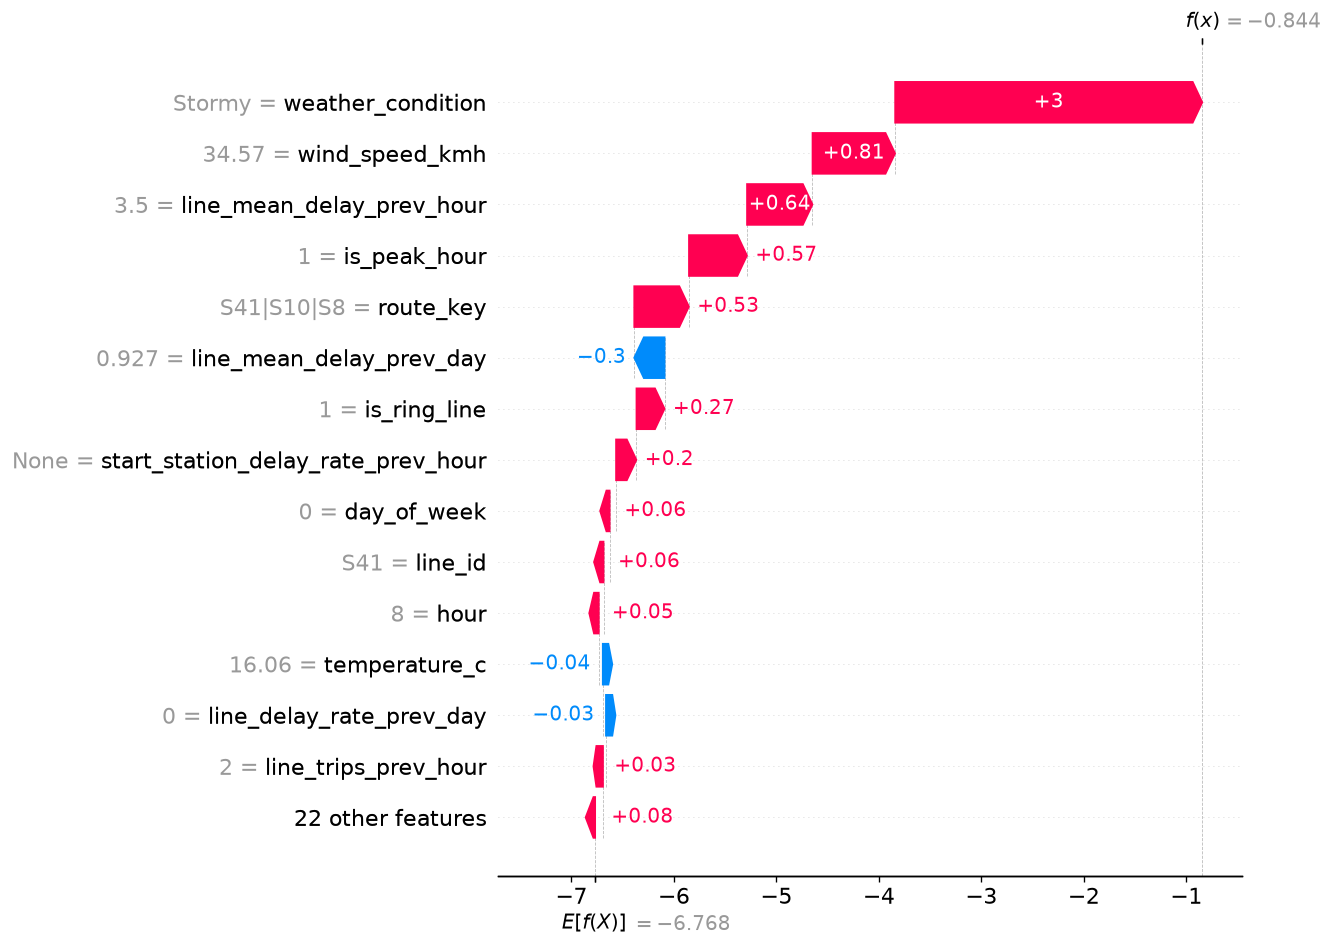

s41_miss: S41 hour 9  probability 0.249  weather_condition +2.580


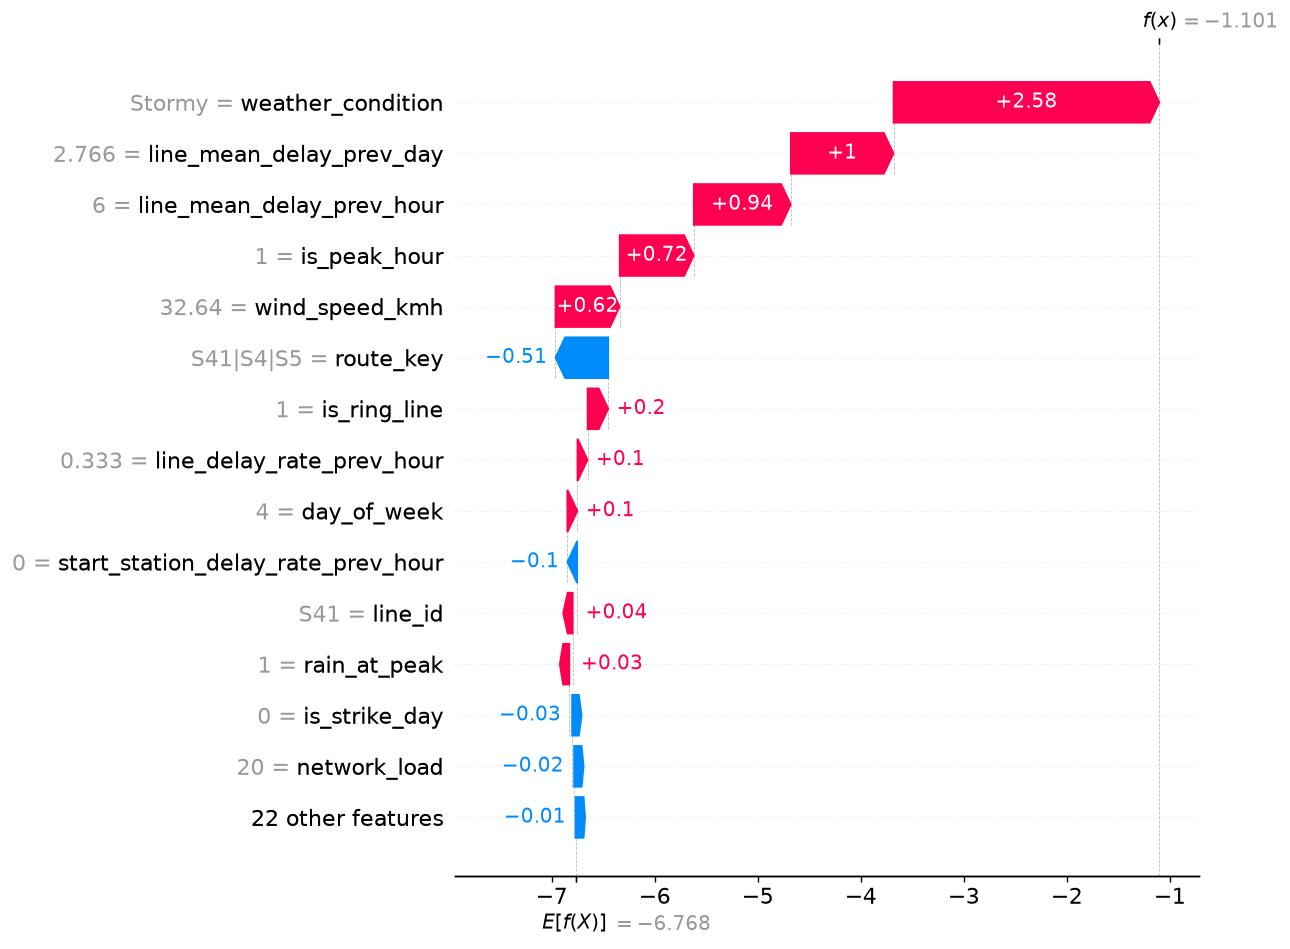

In [1]:
import json

from IPython.display import Image, display

from sbahn.config import PROJECT_ROOT

figures = PROJECT_ROOT / "reports" / "figures"
importance = json.loads(
    (PROJECT_ROOT / "reports" / "evaluation" / "shap_importance.json").read_text(encoding="utf-8")
)
cases = json.loads(
    (PROJECT_ROOT / "reports" / "evaluation" / "shap_cases.json").read_text(encoding="utf-8")
)
print(f"expected log-odds {cases['base_value']:.3f}")
for row in importance["features"][:8]:
    print(f"{row['rank']:2d}  {row['name']}  {row['mean_abs_shap']:.3f}")
display(Image(filename=str(figures / "shap_importance.png")))
display(Image(filename=str(figures / "shap_beeswarm.png")))
for case in cases["cases"]:
    lead = case["contributions"][0]
    print(
        f"{case['role']}: {case['line_id']} hour {case['hour']}  "
        f"probability {case['probability']:.3f}  "
        f"{lead['feature']} {lead['shap']:+.3f}"
    )
    display(Image(filename=str(figures / f"shap_waterfall_{case['role']}.png")))


The largest contributions are the previous hour's mean delay on the line, the weather condition, the route, and the previous day's mean delay. A high recent delay pushes the log-odds up. A strike day does too, and when the flag is on it is a large push even though it ranks fifth overall, because most trips are not strike days.

The caught strike delay is an S41 trip at 08:00 with probability 0.304. `is_strike_day` adds +5.01. The ordinary-day miss is an S42 trip at 09:00 with probability 0.279: stormy weather, the peak flag, and a recent mean delay of 3.5 minutes all push toward delay, and the sum stays under 0.30. The ordinary-day false alarm is an S41 trip at 08:00 with probability 0.301, pushed over the cutoff by the same kind of weather and recent delay. The S41 miss, at 09:00 with probability 0.249, is pushed up by stormy weather and recent delay, and its route pulls it back down.